# Personal Knowledge System: A Prototype

**Offir Olivkovich**

---

This notebook implements a prototype Personal Knowledge System (PKS) that transforms unstructured thought streams into a structured, queryable idea graph.

### Core Concept

Multi-domain thinkers often generate ideas across many areas, yet these ideas frequently remain scattered, disconnected, and difficult to revisit.

When captured as a stream of consciousness, thought is typically represented as linear text. In this form, ideas can become fragmented, buried, or hard to recover.

Using an LLM to structure raw thoughts is a useful first step, but it remains limited: the output is still linear text, and the structure is shallow and uneven.

The aim of this notebook is to move beyond that, by treating ideas as structured units and organizing them into a system.

### Interaction Model

The user provides a raw stream of thoughts, written freely without the need for structure or formatting. This may include ideas, questions, reflections, or partial fragments captured in a single session.

This input is then processed into a set of atomic ideas. Each idea is extracted, structured, enriched with metadata, and integrated into a growing network of connected thoughts.

Once processed, the user can interact with their ideas in several ways:

- Search for ideas based on semantic meaning rather than exact wording  
- Explore related ideas through similarity-based connections  
- View ideas originating from the same session  
- Filter ideas by domain, type, or tags  
- Navigate the system as a graph of interconnected ideas  

Instead of revisiting notes as linear text, the user interacts with a structured system where ideas are linked, queryable, and continuously expandable.

In [1]:
# INSTALL DEPENDENCIES
%pip install pandas numpy openai sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
# IMPORTS

# =========================
# standard library
# =========================
import os
import re
import json
import uuid
import sqlite3
import webbrowser
from pathlib import Path
from datetime import datetime, UTC

# =========================
# typing & data structures
# =========================
from typing import List, Optional, Dict
from dataclasses import dataclass, field, asdict

# =========================
# data handling
# =========================
import pandas as pd
import numpy as np

# =========================
# machine learning / embeddings
# =========================
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# llm / api
# =========================
from openai import OpenAI

# =========================
# graph & visualization
# =========================
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

# =========================
# notebook display
# =========================
from IPython.display import display, HTML, Markdown

## 1. Data Model

First, we require a clear and consistent definition of what constitutes a 'processed idea'. The term "idea" is used in a broad sense, closer to its original meaning as a form or mental representation, rather than a fully developed concept.

At the core of this system is the concept of an *atomic idea*: a self-contained unit of thought that can be stored, represented as a vector, and related to other ideas through both structural and semantic connections.

<!-- Each idea is extracted from a user inputed 'stream-of-consciousness' then enriched with LLM-generated metadata, linked to its originating session, and embedded for semantic comparison.
Defining this schema establishes a structured foundation for the system. Rather than treating notes as unstructured text, ideas are represented as normalized records that can be queried, compared, and extended over time. -->


### 1.1 Application Data Model

#### 1.1.1 `IdeaRecord` Structure

Each processed idea is represented using the following fields:

- `idea_id` *(system)*: Unique identifier for the idea  
- `session_id` *(system)*: Identifier shared by all ideas extracted from the same input session  
- `text` *(llm)*: The full atomic idea text  
- `summary` *(llm)*: A concise summary of the idea  
- `main_domain` *(llm)*: Primary domain of the idea  
- `sub_domains` *(llm)*: Secondary related domains  
- `idea_type` *(llm)*: Category such as idea, thought, project, fear, aspiration, goal, or task  
- `tags` *(llm)*: Short descriptive labels  
- `embedding` *(system)*: Vector representation used for semantic similarity and search  
- `created_at` *(system)*: Timestamp for storage and tracking  

Each field is either inferred from the raw input by the LLM or assigned by the system during processing, reflecting a separation between semantic interpretation and system-level responsibilities.

In [3]:
# Creating the IdeaRecord class
@dataclass
class IdeaRecord:
    idea_id: str
    session_id: str
    text: str
    summary: str
    main_domain: str
    sub_domains: List[str] = field(default_factory=list)
    idea_type: str = ""
    tags: List[str] = field(default_factory=list)
    embedding: Optional[List[float]] = None
    created_at: str = field(default_factory=lambda: datetime.now(UTC).isoformat())

#### 1.1.2 `SessionRecord` Structure

A session represents a single raw input from the user before any processing occurs. It preserves the original context from which atomic ideas are later extracted.

Each session contains:

- `session_id`: Unique identifier for the raw input  
- `raw_dump`: The original unprocessed text  
- `created_at`: Timestamp of ingestion  

All ideas extracted from the same input inherit the same `session_id`, allowing the system to preserve local context alongside semantic relationships between ideas.

In [4]:
# Creating the SessionRecord class
@dataclass
class SessionRecord:
    session_id: str = field(default_factory=lambda: str(uuid.uuid4()))
    raw_dump: str = ""
    created_at: str = field(default_factory=lambda: datetime.now(UTC).isoformat())

### 1.2 Relational Storage Design

The Python data model defines the main application-level objects used by the pipeline: `SessionRecord` and `IdeaRecord`.

The database schema decomposes them into relational tables so that repeated metadata, embeddings, and links can be stored efficiently and queried cleanly:

#### Table Roles

- `sessions` — stores the original raw input (one row per session)

- `ideas` — stores the extracted and normalized ideas

- `domains` — stores unique subdomain values (to avoid duplication)

- `idea_subdomains` — links ideas to their subdomains

- `tags` — stores unique tag values

- `idea_tags` — links ideas to their tags

- `embeddings` — stores vector representations of ideas (separate from metadata)

- `idea_links` — stores relationships between ideas (e.g. similarity or same-session links)

---

The following image shows the schema as a UML diagram.

<img src="../images/mermaid_uml.png" width="70%">

## 2. Database Setup

The system uses a database to store ideas long-term, enabling connections between ideas across different sessions.

SQLite is chosen because it is lightweight, portable, and ideal for a self-contained prototype.

### 2.1 Database Path and Connection

In [5]:
DB_DIR = Path("../data")
DB_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = DB_DIR / "pks.sqlite"


def get_connection(db_path: Path = DB_PATH) -> sqlite3.Connection:
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    return conn

### 2.2 Schema Initialization

Tables are created using `CREATE TABLE IF NOT EXISTS`, ensuring that:

- The first run initializes the schema  
- Subsequent runs reuse existing tables  
- Data is preserved unless explicitly reset  

In [6]:
def init_db(conn: sqlite3.Connection) -> None:
    cursor = conn.cursor()

    cursor.executescript(
        """
        CREATE TABLE IF NOT EXISTS sessions (
            session_id TEXT PRIMARY KEY,
            raw_dump TEXT NOT NULL,
            created_at TEXT NOT NULL
        );

        CREATE TABLE IF NOT EXISTS ideas (
            idea_id TEXT PRIMARY KEY,
            session_id TEXT NOT NULL,
            text TEXT NOT NULL,
            summary TEXT NOT NULL,
            main_domain TEXT NOT NULL,
            idea_type TEXT NOT NULL,
            created_at TEXT NOT NULL,
            FOREIGN KEY (session_id) REFERENCES sessions(session_id)
        );

        CREATE TABLE IF NOT EXISTS domains (
            domain_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL UNIQUE
        );

        CREATE TABLE IF NOT EXISTS idea_subdomains (
            idea_id TEXT NOT NULL,
            domain_id INTEGER NOT NULL,
            PRIMARY KEY (idea_id, domain_id),
            FOREIGN KEY (idea_id) REFERENCES ideas(idea_id),
            FOREIGN KEY (domain_id) REFERENCES domains(domain_id)
        );

        CREATE TABLE IF NOT EXISTS tags (
            tag_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL UNIQUE
        );

        CREATE TABLE IF NOT EXISTS idea_tags (
            idea_id TEXT NOT NULL,
            tag_id INTEGER NOT NULL,
            PRIMARY KEY (idea_id, tag_id),
            FOREIGN KEY (idea_id) REFERENCES ideas(idea_id),
            FOREIGN KEY (tag_id) REFERENCES tags(tag_id)
        );

        CREATE TABLE IF NOT EXISTS embeddings (
            idea_id TEXT PRIMARY KEY,
            vector_json TEXT NOT NULL,
            FOREIGN KEY (idea_id) REFERENCES ideas(idea_id)
        );

        CREATE TABLE IF NOT EXISTS idea_links (
            source_idea_id TEXT NOT NULL,
            target_idea_id TEXT NOT NULL,
            link_type TEXT NOT NULL,
            score REAL,
            PRIMARY KEY (source_idea_id, target_idea_id, link_type),
            FOREIGN KEY (source_idea_id) REFERENCES ideas(idea_id),
            FOREIGN KEY (target_idea_id) REFERENCES ideas(idea_id)
        );
        """
    )

    conn.commit()

### 2.3 Database Operation Helpers

The following helper functions provide reusable operations for interacting with the database.

#### 2.3.1 Development Helpers

The reset helper is used during development to clear all tables.

It is not executed by default and should be used with caution.

In [7]:
def reset_database(conn: sqlite3.Connection) -> None:
    cursor = conn.cursor()
    cursor.executescript(
        """
        DROP TABLE IF EXISTS idea_links;
        DROP TABLE IF EXISTS embeddings;
        DROP TABLE IF EXISTS idea_tags;
        DROP TABLE IF EXISTS tags;
        DROP TABLE IF EXISTS idea_subdomains;
        DROP TABLE IF EXISTS domains;
        DROP TABLE IF EXISTS ideas;
        DROP TABLE IF EXISTS sessions;
        """
    )
    conn.commit()

#### 2.3.2 Insert Helpers

These functions handle inserting sessions, ideas, and associated metadata into the database.

They ensure that data is stored in a normalized and consistent format.

In [8]:
def insert_session(conn: sqlite3.Connection, session: SessionRecord) -> None:
    cursor = conn.cursor()
    cursor.execute(
        """
        INSERT OR REPLACE INTO sessions (session_id, raw_dump, created_at)
        VALUES (?, ?, ?)
        """,
        (session.session_id, session.raw_dump, session.created_at),
    )
    conn.commit()

In [9]:
def insert_idea(conn: sqlite3.Connection, record: IdeaRecord) -> None:
    cursor = conn.cursor()
    cursor.execute(
        """
        INSERT OR REPLACE INTO ideas (
            idea_id, session_id, text, summary, main_domain, idea_type, created_at
        )
        VALUES (?, ?, ?, ?, ?, ?, ?)
        """,
        (
            record.idea_id,
            record.session_id,
            record.text,
            record.summary,
            record.main_domain,
            record.idea_type,
            record.created_at,
        ),
    )
    conn.commit()

In [10]:
def get_or_create_domain_id(conn: sqlite3.Connection, domain_name: str) -> int:
    domain_name = domain_name.strip().lower()
    cursor = conn.cursor()

    cursor.execute("INSERT OR IGNORE INTO domains (name) VALUES (?)", (domain_name,))
    cursor.execute("SELECT domain_id FROM domains WHERE name = ?", (domain_name,))
    row = cursor.fetchone()

    if row is None:
        raise ValueError(f"could not retrieve domain_id for domain: {domain_name}")

    conn.commit()
    return row["domain_id"]

In [11]:
def insert_idea_subdomains(conn: sqlite3.Connection, record: IdeaRecord) -> None:
    cursor = conn.cursor()

    for domain_name in record.sub_domains:
        domain_id = get_or_create_domain_id(conn, domain_name)
        cursor.execute(
            """
            INSERT OR IGNORE INTO idea_subdomains (idea_id, domain_id)
            VALUES (?, ?)
        """,
            (record.idea_id, domain_id),
        )

    conn.commit()

In [12]:
def get_or_create_tag_id(conn: sqlite3.Connection, tag_name: str) -> int:
    tag_name = tag_name.strip().lower()
    cursor = conn.cursor()

    cursor.execute("INSERT OR IGNORE INTO tags (name) VALUES (?)", (tag_name,))
    cursor.execute("SELECT tag_id FROM tags WHERE name = ?", (tag_name,))
    row = cursor.fetchone()

    if row is None:
        raise ValueError(f"could not retrieve tag_id for tag: {tag_name}")

    conn.commit()
    return row["tag_id"]

In [13]:
def insert_idea_tags(conn: sqlite3.Connection, record: IdeaRecord) -> None:
    cursor = conn.cursor()

    for tag_name in record.tags:
        tag_id = get_or_create_tag_id(conn, tag_name)
        cursor.execute(
            """
            INSERT OR IGNORE INTO idea_tags (idea_id, tag_id)
            VALUES (?, ?)
        """,
            (record.idea_id, tag_id),
        )

    conn.commit()

In [14]:
def insert_embedding(conn: sqlite3.Connection, record: IdeaRecord) -> None:
    if record.embedding is None:
        raise ValueError("cannot store embedding for a record with embedding=None")

    cursor = conn.cursor()
    cursor.execute(
        """
        INSERT OR REPLACE INTO embeddings (idea_id, vector_json)
        VALUES (?, ?)
    """,
        (record.idea_id, json.dumps(record.embedding)),
    )
    conn.commit()

#### 2.3.3 Storing a Full Idea Record

A complete idea record spans multiple tables:

- The main idea row  
- Subdomain mappings  
- Tag mappings  
- Embedding storage  

The helper below performs the full insert process.

In [15]:
def insert_full_idea_record(conn: sqlite3.Connection, record: IdeaRecord) -> None:
    insert_idea(conn, record)
    insert_idea_subdomains(conn, record)
    insert_idea_tags(conn, record)

    if record.embedding is not None:
        insert_embedding(conn, record)

### 2.4 Initializing the Database

The following cell establishes the database connection and ensures that the schema is initialized.

This operation is safe to rerun.

In [16]:
RESET_DB = False

conn = get_connection()

if RESET_DB:
    reset_database(conn)

init_db(conn)

### 2.5 Database Preview

The following queries provide a lightweight inspection of the current database contents.

Together, they confirm that sessions, ideas, embeddings, and normalized metadata are being stored correctly.

#### Stored Sessions

The query below shows the raw session records currently stored in the database.

In [17]:
sessions_df = pd.read_sql_query("SELECT * FROM sessions", conn)
sessions_df

,session_id,raw_dump,created_at
0,7aebcbed-82e4-4934-9112-43aea09b0dac,I’ve been thinking about how memory actually r...,2026-03-28T14:47:18.897073+00:00
1,1603ecd0-9ccf-48c6-9948-4f19730930dd,Most “new” ideas I have feel like combinations...,2026-03-28T14:53:48.427994+00:00
2,b7e19f6e-d870-418f-9bde-38d8ef7006d7,What determines how creative someone will be? ...,2026-03-28T14:56:40.553169+00:00
3,20446695-3823-4d0c-a33c-cd623cfbe9e7,I feel like motivation is tied more to energy ...,2026-03-28T14:59:28.936886+00:00
4,5b60d264-bcf5-43a3-bf00-0ec67bd7683a,Today I learned there is a relationship betwee...,2026-03-28T15:03:03.553717+00:00
5,44117871-5fdb-4bcb-a5e3-c314d07d8b15,I cant really seem to remember a lot from my c...,2026-03-28T15:04:44.537624+00:00
6,90f067d9-4f65-4aaa-8a4a-1a7f8d5dc7e0,Before I fall asleep I see colors and hear mus...,2026-03-28T18:47:53.049018+00:00
7,da86a9c8-c53a-4cf9-9c43-92e364290b2a,Before I fall asleep I see colors and hear mus...,2026-03-28T18:50:51.797792+00:00
8,65aab382-f76b-4766-919a-9115b3862ec2,I think there should be a designated app for e...,2026-03-28T18:58:50.214093+00:00
9,408db844-f30e-48f0-90d7-78c2a581ac58,I think there should be a designated app for e...,2026-03-28T19:03:02.754411+00:00


#### Stored Ideas

The query below shows the main normalized idea records stored in the `ideas` table.

In [18]:
ideas_df = pd.read_sql_query("SELECT * FROM ideas", conn)
ideas_df

,idea_id,session_id,text,summary,main_domain,idea_type,created_at
0,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,7aebcbed-82e4-4934-9112-43aea09b0dac,Memory reconstructs experiences rather than st...,Memory reconstructs rather than stores experie...,cognitive science,idea,2026-03-28T14:47:26.006551+00:00
1,bc177d25-394c-404f-93ec-7ad9cce22340,7aebcbed-82e4-4934-9112-43aea09b0dac,This reconstruction process makes the reliabil...,Recollection reliability is questionable due t...,psychology,thought,2026-03-28T14:47:26.006551+00:00
2,0bfcf607-59e5-413d-ac6a-7c90d9dda7ad,7aebcbed-82e4-4934-9112-43aea09b0dac,There might be a way to model the distortion c...,Potential to model distortion in memory recons...,computational modeling,idea,2026-03-28T14:47:26.006551+00:00
3,cbc43c93-5379-4eec-89ca-287fe94a9f67,1603ecd0-9ccf-48c6-9948-4f19730930dd,Most new ideas I have feel like combinations o...,Creativity may be combining existing ideas in ...,creativity,thought,2026-03-28T14:53:52.865674+00:00
4,3276fe87-49f0-40fa-8bf1-50ce5c7411ed,1603ecd0-9ccf-48c6-9948-4f19730930dd,It could be interesting to create a model that...,Propose building a model of idea formation usi...,artificial intelligence,idea,2026-03-28T14:53:52.865674+00:00
...,...,...,...,...,...,...,...
58,05da98cb-c03b-4d07-9aa8-f5063c568d67,65aab382-f76b-4766-919a-9115b3862ec2,Existing apps are not very good at browsing ev...,Current event apps have usability shortcomings.,technology,thought,2026-03-28T18:58:56.077490+00:00
59,de70ccc7-8661-42ce-8c66-ee8961fd4df2,408db844-f30e-48f0-90d7-78c2a581ac58,There should be a designated app for events wh...,Need for an app to browse events by category.,technology,idea,2026-03-28T19:03:07.752489+00:00
60,4d3d52c8-f484-492a-94a7-90e8a4d719aa,408db844-f30e-48f0-90d7-78c2a581ac58,The app should allow users to see which events...,App feature to view friends' event interests.,technology,idea,2026-03-28T19:03:07.752489+00:00
61,cab9ca26-c665-4728-9024-2bbcffcdfc06,408db844-f30e-48f0-90d7-78c2a581ac58,The app should enable easy sharing of events w...,Feature for easy event sharing with friends.,technology,idea,2026-03-28T19:03:07.752489+00:00


#### Stored Embeddings

To keep the preview readable, the embedding table is summarized using vector dimensionality and a short prefix of each embedding rather than displaying the full vector.

In [19]:
embedding_rows = pd.read_sql_query("SELECT * FROM embeddings", conn)

embedding_rows["embedding_dim"] = embedding_rows["vector_json"].apply(
    lambda x: len(json.loads(x))
)
embedding_rows["embedding_preview"] = embedding_rows["vector_json"].apply(
    lambda x: json.loads(x)[:5]
)

embedding_rows[["idea_id", "embedding_dim", "embedding_preview"]]

,idea_id,embedding_dim,embedding_preview
0,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,384,"[0.05038769170641899, -0.004438311327248812, -..."
1,bc177d25-394c-404f-93ec-7ad9cce22340,384,"[-0.023540213704109192, -0.006194594781845808,..."
2,0bfcf607-59e5-413d-ac6a-7c90d9dda7ad,384,"[-0.06340360641479492, -0.05267441272735596, -..."
3,cbc43c93-5379-4eec-89ca-287fe94a9f67,384,"[-0.0008057798258960247, -0.10861574113368988,..."
4,3276fe87-49f0-40fa-8bf1-50ce5c7411ed,384,"[0.01304252352565527, -0.08966626971960068, -0..."
...,...,...,...
58,05da98cb-c03b-4d07-9aa8-f5063c568d67,384,"[-0.015903184190392494, -0.03548969328403473, ..."
59,de70ccc7-8661-42ce-8c66-ee8961fd4df2,384,"[0.03630528226494789, -0.039471592754125595, -..."
60,4d3d52c8-f484-492a-94a7-90e8a4d719aa,384,"[-0.010179641656577587, 0.022599460557103157, ..."
61,cab9ca26-c665-4728-9024-2bbcffcdfc06,384,"[-0.07640017569065094, -0.0032360933255404234,..."


#### Normalized Domains and Tags

The following queries show that subdomains and tags are stored through normalized reference and mapping tables rather than repeated directly inside each idea record.

In [20]:
domains_df = pd.read_sql_query("SELECT * FROM domains", conn)
idea_subdomains_df = pd.read_sql_query("SELECT * FROM idea_subdomains", conn)
tags_df = pd.read_sql_query("SELECT * FROM tags", conn)
idea_tags_df = pd.read_sql_query("SELECT * FROM idea_tags", conn)

display(domains_df)
display(idea_subdomains_df)
display(tags_df)
display(idea_tags_df)

,domain_id,name
0,1,neuroscience
1,2,psychology
2,3,cognitive science
3,4,memory studies
4,8,innovation
5,9,creativity
6,10,knowledge management
7,11,modeling
8,13,environmental psychology
9,14,brain function


,idea_id,domain_id
0,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,1
1,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,2
2,bc177d25-394c-404f-93ec-7ad9cce22340,3
3,bc177d25-394c-404f-93ec-7ad9cce22340,4
4,0bfcf607-59e5-413d-ac6a-7c90d9dda7ad,3
...,...,...
129,4d3d52c8-f484-492a-94a7-90e8a4d719aa,119
130,cab9ca26-c665-4728-9024-2bbcffcdfc06,121
131,cab9ca26-c665-4728-9024-2bbcffcdfc06,119
132,22d781bd-7497-4496-9844-76a570d7e7dc,127


,tag_id,name
0,1,memory
1,2,reconstruction
2,3,cognition
3,4,experience
4,5,neuroscience
...,...,...
66,260,interests
67,261,sharing
68,268,apps
69,269,usability


,idea_id,tag_id
0,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,1
1,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,2
2,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,3
3,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,4
4,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,5
...,...,...
282,cab9ca26-c665-4728-9024-2bbcffcdfc06,259
283,22d781bd-7497-4496-9844-76a570d7e7dc,252
284,22d781bd-7497-4496-9844-76a570d7e7dc,268
285,22d781bd-7497-4496-9844-76a570d7e7dc,256


## 3. Knowledge Construction Pipeline

With the data model defined, the system applies a processing pipeline to the outputs of the LLM extraction stage.

After raw input is transformed into structured payloads by the LLM, this pipeline validates the data, normalizes it into a consistent `IdeaRecord`, and prepares it for embedding and storage. This step converts probabilistic model outputs into reliable and structured system data.

The following sections describe the two stages and conclude with an example execution of the pipeline.

### 3.1 Input and Ingestion Layer

The system receives input as a "raw idea dump": a free-form text session containing multiple thoughts captured in a single input.

Each raw dump is treated as a single session. This assigns the input a stable identity within the system before any extraction takes place.

Preserving input at the session level is important because ideas are not only meaningful as isolated semantic units. They also carry contextual value based on when and how they were generated together. By maintaining session boundaries, the system can preserve local context and later recover relationships between ideas extracted from the same input.

Before any LLM-based extraction occurs, the raw input is wrapped into a `SessionRecord`. This ensures that all downstream ideas can be traced back to their original session context.

In [21]:
def create_session(raw_dump: str) -> SessionRecord:
    raw_dump = raw_dump.strip()
    if not raw_dump:
        raise ValueError("raw_dump must be a non-empty string")

    return SessionRecord(
        session_id=str(uuid.uuid4()),
        raw_dump=raw_dump,
        created_at=datetime.now(UTC).isoformat(),
    )

### 3.2. Extraction Layer

Once a raw dump has been captured as a session, the next step is to extract atomic ideas.

The system does not treat the raw dump as a single note. Instead, an LLM is used to identify distinct concepts within the text and return them as independently structured idea units.

The goal is not sentence splitting, but concept-level extraction.

A single raw dump may contain multiple projects, reflections, goals, or associations. If these remain merged, the system cannot represent them clearly, compute relationships accurately, or preserve structure over time.

#### 3.2.1 Extraction Rules

The LLM extraction stage must follow these constraints:

- Split by concept, not by sentence
- Preserve distinct ideas without over-merging
- Avoid duplicate ideas
- Do not invent unsupported details
- Return strict JSON only

Each extracted idea must include:

- `text`
- `summary`
- `main_domain`
- `sub_domains`
- `idea_type`
- `tags`

The following fields are added later by the system:

- `idea_id`
- `session_id`
- `embedding`
- `created_at`

#### 3.2.2 Expected Output Schema

The LLM is expected to return a JSON array in which each item represents one extracted atomic idea.

At this stage, the output is still an intermediate payload. After parsing and validation, each item is converted into a normalized `IdeaRecord` for downstream storage and graph construction.

In [22]:
EXPECTED_LLM_IDEA_SCHEMA = {
    "text": "str",
    "summary": "str",
    "main_domain": "str",
    "sub_domains": "list[str]",
    "idea_type": "str",
    "tags": "list[str]",
}

#### 3.2.3 Prompt Construction

The prompt below is designed to keep the extraction stage narrow and controlled.

It frames the task as structured idea extraction rather than conversation. This helps the LLM produce stable, machine-readable output that the rest of the pipeline can validate and store safely.

In [23]:
def build_extraction_prompt(raw_dump: str) -> str:
    return f"""
you are extracting atomic ideas from a raw idea dump.

your task:
- split the dump into atomic ideas by concept, not by sentence
- preserve distinct ideas and do not over-merge them
- do not invent information that is not supported by the text
- output strict json only
- return a json array
- each item must contain exactly these fields:
  - text
  - summary
  - main_domain
  - sub_domains
  - idea_type
  - tags

field requirements:
- text: the full atomic idea in clean prose
- summary: short summary of the idea
- main_domain: one primary domain
- sub_domains: list of related domains
- idea_type: one of idea, thought, project, fear, aspiration, goal, task, or another clearly fitting label
- tags: list of 3 to 6 short tags

raw idea dump:
\"\"\"
{raw_dump}
\"\"\"

return only strict json.
""".strip()

#### 3.2.4 LLM Extraction Function

The functions below handle two tasks:

1. Building the extraction prompt
2. Parsing the model response into a JSON array

The extraction call is isolated in a single function so that the prompting layer can be adjusted later without changing the rest of the pipeline.

In [24]:
def extract_json_array_from_text(text: str) -> list:
    text = text.strip()

    try:
        parsed = json.loads(text)
        if not isinstance(parsed, list):
            raise ValueError("llm output must be a json array")
        return parsed
    except json.JSONDecodeError:
        pass

    match = re.search(r"\[\s*{.*}\s*\]", text, flags=re.DOTALL)
    if not match:
        raise ValueError("could not find a valid json array in llm output")

    parsed = json.loads(match.group(0))
    if not isinstance(parsed, list):
        raise ValueError("extracted json payload is not a list")

    return parsed

The notebook assumes that an LLM client is available in the execution environment. The client setup itself is environment-specific, so it is kept minimal here.

In [ ]:
os.environ["OPENAI_API_KEY"] = (
    "sk-proj-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" 
)

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [26]:
def call_extraction_llm(raw_dump: str) -> list[dict]:
    prompt = build_extraction_prompt(raw_dump)

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )

    output_text = response.choices[0].message.content.strip()
    items = extract_json_array_from_text(output_text)
    return items

#### 3.2.5 Prompt Preview

The prompt can be inspected to verify that the task framing and output constraints are explicit.

In [27]:
example_raw_dump = """Build an app to organize saved TikToks and I want to create a swarm robot that forms structures"""

print(build_extraction_prompt(example_raw_dump))

you are extracting atomic ideas from a raw idea dump.

your task:
- split the dump into atomic ideas by concept, not by sentence
- preserve distinct ideas and do not over-merge them
- do not invent information that is not supported by the text
- output strict json only
- return a json array
- each item must contain exactly these fields:
  - text
  - summary
  - main_domain
  - sub_domains
  - idea_type
  - tags

field requirements:
- text: the full atomic idea in clean prose
- summary: short summary of the idea
- main_domain: one primary domain
- sub_domains: list of related domains
- idea_type: one of idea, thought, project, fear, aspiration, goal, task, or another clearly fitting label
- tags: list of 3 to 6 short tags

raw idea dump:
"""
Build an app to organize saved TikToks and I want to create a swarm robot that forms structures
"""

return only strict json.


### 3.3 Validation

LLM output cannot be assumed to be reliable, so each extracted payload is validated before it enters the system.

This step checks that all required fields are present and that each field matches the expected structure. Validation prevents malformed outputs from propagating into later stages such as normalization, embedding generation, storage, and graph construction.

In [28]:
REQUIRED_IDEA_FIELDS = {
    "text",
    "summary",
    "main_domain",
    "sub_domains",
    "idea_type",
    "tags",
}


def validate_llm_idea_payload(payload: dict) -> None:
    missing = REQUIRED_IDEA_FIELDS - payload.keys()
    if missing:
        raise ValueError(f"missing required fields: {sorted(missing)}")

    if not isinstance(payload["text"], str) or not payload["text"].strip():
        raise ValueError("text must be a non-empty string")

    if not isinstance(payload["summary"], str) or not payload["summary"].strip():
        raise ValueError("summary must be a non-empty string")

    if (
        not isinstance(payload["main_domain"], str)
        or not payload["main_domain"].strip()
    ):
        raise ValueError("main_domain must be a non-empty string")

    if not isinstance(payload["sub_domains"], list):
        raise ValueError("sub_domains must be a list")

    if not isinstance(payload["tags"], list):
        raise ValueError("tags must be a list")

    if not isinstance(payload["idea_type"], str) or not payload["idea_type"].strip():
        raise ValueError("idea_type must be a non-empty string")

### 3.4 Record Construction

Once a payload passes validation, it is converted into a normalized `IdeaRecord`.

This step attaches system metadata, links the idea back to its originating session, and standardizes selected fields such as casing and formatting. The result is a consistent record structure that is ready for downstream embedding and storage.

In [29]:
def build_idea_record(payload: dict, session_id: str) -> IdeaRecord:
    validate_llm_idea_payload(payload)

    return IdeaRecord(
        idea_id=str(uuid.uuid4()),
        session_id=session_id,
        text=payload["text"].strip(),
        summary=payload["summary"].strip(),
        main_domain=payload["main_domain"].strip().lower(),
        sub_domains=[
            d.strip().lower() for d in payload["sub_domains"] if str(d).strip()
        ],
        idea_type=payload["idea_type"].strip().lower(),
        tags=[t.strip().lower() for t in payload["tags"] if str(t).strip()],
    )


def build_idea_records_from_payloads(
    payloads: list[dict], session_id: str
) -> list[IdeaRecord]:
    return [build_idea_record(payload, session_id) for payload in payloads]

### 3.5 Embedding Layer

Once ideas have been converted into normalized `IdeaRecord` objects, the next step is to generate embeddings.

Embeddings allow the system to operate over semantic meaning rather than keyword overlap. This enables similarity search, clustering, and graph-based relationships between ideas.

#### 3.5.1 Embedding Input Construction

Each embedding requires a text representation of the idea.

To preserve both concise meaning and full context, the system combines the summary and full text into a single input string.

In [30]:
def build_embedding_input(record: IdeaRecord) -> str:
    return f"{record.summary}. {record.text}".strip()

#### 3.5.2 Embedding Generation

The embedding function converts a batch of input texts into vector representations.

This step is kept modular so that the embedding model can be replaced without affecting the rest of the pipeline.

In [31]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


def embed_texts(texts: List[str]) -> List[List[float]]:
    vectors = embedding_model.encode(texts, show_progress_bar=False)
    return [vec.tolist() for vec in vectors]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### 3.5.3 Attaching Embeddings to Records

Once embeddings are generated, they are attached back to their corresponding `IdeaRecord` objects.

This keeps each record self-contained and prepares it for downstream storage, retrieval, and semantic comparison.

In [32]:
def attach_embeddings_to_records(
    records: List[IdeaRecord], embeddings: List[List[float]]
) -> List[IdeaRecord]:
    if len(records) != len(embeddings):
        raise ValueError("number of records must match number of embeddings")

    enriched_records = []
    for record, embedding in zip(records, embeddings):
        enriched_records.append(
            IdeaRecord(
                idea_id=record.idea_id,
                session_id=record.session_id,
                text=record.text,
                summary=record.summary,
                main_domain=record.main_domain,
                sub_domains=record.sub_domains,
                idea_type=record.idea_type,
                tags=record.tags,
                embedding=embedding,
                created_at=record.created_at,
            )
        )

    return enriched_records

#### 3.5.4 End-to-End Embedding Pipeline

The helper below combines embedding input construction, vector generation, and record enrichment into a single reusable stage.

In [33]:
def embed_idea_records(records: List[IdeaRecord]) -> List[IdeaRecord]:
    embedding_inputs = [build_embedding_input(record) for record in records]
    embeddings = embed_texts(embedding_inputs)
    return attach_embeddings_to_records(records, embeddings)

### 3.6 Graph Construction Layer

Once ideas have been normalized and enriched with embeddings, the next step is to connect them into a graph.

The goal of this stage is not only to store ideas, but to represent relationships between them. In PKS, two types of relationships are used:

1. **Semantic relationships**, based on embedding similarity  
2. **Sibling relationships**, based on shared session origin  

Together, these provide both:

- **Global semantic structure**, through similarity across sessions and domains  
- **Local generative context**, through ideas captured within the same raw dump

#### 3.6.1 Similarity Computation

Semantic relationships are computed using cosine similarity between embedding vectors.

For each idea, the system identifies the top-k most similar ideas and stores them as edges in the `idea_links` table.

In [34]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

#### 3.6.2 Loading Embeddings

To compute semantic relationships, stored embedding vectors are loaded from the database and converted back into numerical arrays.

In [35]:
def load_embeddings(conn):
    cursor = conn.cursor()
    cursor.execute("SELECT idea_id, vector_json FROM embeddings")
    rows = cursor.fetchall()

    embeddings = {}
    for idea_id, vector_json in rows:
        embeddings[idea_id] = json.loads(vector_json)

    return embeddings

#### 3.6.3 Building Semantic Links

For each idea, the system compares its embedding to all other stored embeddings, selects the top-k most similar ideas, and stores those relationships in the `idea_links` table.

In [ ]:
def build_semantic_links(conn, top_k=3):
    cursor = conn.cursor()
    
    cursor.execute("DELETE FROM idea_links WHERE link_type = 'semantic'")

    embeddings = load_embeddings(conn)
    idea_ids = list(embeddings.keys())

    links = []

    for source_id in idea_ids:
        sims = []

        for target_id in idea_ids:
            if source_id == target_id:
                continue

            sim = cosine_similarity(embeddings[source_id], embeddings[target_id])
            sims.append((target_id, sim))

        sims.sort(key=lambda x: x[1], reverse=True)
        top = sims[:top_k]

        for target_id, score in top:
            links.append((source_id, target_id, "semantic", float(score)))

    cursor.executemany(
        """
        INSERT INTO idea_links (source_idea_id, target_idea_id, link_type, score)
        VALUES (?, ?, ?, ?)
        """,
        links,
    )

    conn.commit()

#### 3.6.4 Sibling Relationships

In addition to semantic similarity, ideas are also related through shared session origin.

Ideas extracted from the same session are treated as siblings, even if they are not semantically close. This preserves the local structure of the original raw dump.

In [37]:
def get_sibling_ideas(conn, idea_id):
    cursor = conn.cursor()

    cursor.execute(
        """
        SELECT session_id
        FROM ideas
        WHERE idea_id = ?
        """,
        (idea_id,),
    )
    row = cursor.fetchone()
    if row is None:
        return []

    session_id = row[0]

    cursor.execute(
        """
        SELECT idea_id, summary
        FROM ideas
        WHERE session_id = ? AND idea_id != ?
        """,
        (session_id, idea_id),
    )

    return cursor.fetchall()

#### 3.6.5 Graph Exploration Helpers

The following helper functions support semantic and structural exploration of the idea graph.

In [38]:
def list_ideas(conn):
    cursor = conn.cursor()
    cursor.execute("SELECT idea_id, text FROM ideas")
    return cursor.fetchall()


def get_idea_by_id(conn, idea_id):
    cursor = conn.cursor()
    cursor.execute(
        """
        SELECT idea_id, text, summary
        FROM ideas
        WHERE idea_id = ?
        """,
        (idea_id,),
    )
    return cursor.fetchone()


def get_related_ideas(conn, idea_id, limit=5, link_type="semantic"):
    cursor = conn.cursor()

    cursor.execute(
        """
        SELECT session_id
        FROM ideas
        WHERE idea_id = ?
        """,
        (idea_id,),
    )
    row = cursor.fetchone()
    if row is None:
        return []

    source_session_id = row[0]

    cursor.execute(
        """
        SELECT target_idea_id, score
        FROM idea_links
        WHERE source_idea_id = ? AND link_type = ?
        ORDER BY score DESC
        LIMIT ?
        """,
        (idea_id, link_type, limit),
    )

    results = cursor.fetchall()

    enriched = []
    for related_id, score in results:
        cursor.execute(
            """
            SELECT summary, session_id
            FROM ideas
            WHERE idea_id = ?
            """,
            (related_id,),
        )
        related_row = cursor.fetchone()

        if related_row is None:
            continue

        summary, related_session_id = related_row
        is_sibling = related_session_id == source_session_id

        enriched.append((related_id, summary, score, is_sibling))

    return enriched


def semantic_search(conn, query_vector, limit=5):
    embeddings = load_embeddings(conn)

    sims = []
    for idea_id, vec in embeddings.items():
        sim = cosine_similarity(query_vector, vec)
        sims.append((idea_id, sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    top = sims[:limit]

    cursor = conn.cursor()
    results = []

    for idea_id, score in top:
        cursor.execute("SELECT text FROM ideas WHERE idea_id = ?", (idea_id,))
        text = cursor.fetchone()[0]
        results.append((idea_id, text, score))

    return results


def embed_query(text):
    return embed_texts([text])[0]

#### 3.6.6 Graph Preview

The following cells construct semantic links and preview the resulting graph structure.

In [39]:
build_semantic_links(conn)

In [40]:
pd.read_sql_query(
    """
    SELECT source_idea_id, target_idea_id, link_type, score
    FROM idea_links
    WHERE link_type = 'semantic'
    ORDER BY score DESC
    LIMIT 10
    """,
    conn,
)

,source_idea_id,target_idea_id,link_type,score
0,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,96a7ee86-dabc-4524-8994-d119a978b087,semantic,1.0
1,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,semantic,1.0
2,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,98f3e531-906f-419a-b04a-83363c166102,semantic,1.0
3,96a7ee86-dabc-4524-8994-d119a978b087,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,semantic,1.0
4,96a7ee86-dabc-4524-8994-d119a978b087,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,semantic,1.0
5,96a7ee86-dabc-4524-8994-d119a978b087,98f3e531-906f-419a-b04a-83363c166102,semantic,1.0
6,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,semantic,1.0
7,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,96a7ee86-dabc-4524-8994-d119a978b087,semantic,1.0
8,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,98f3e531-906f-419a-b04a-83363c166102,semantic,1.0
9,98f3e531-906f-419a-b04a-83363c166102,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,semantic,1.0


### 3.7 Example: Processing a Session

The following example demonstrates how a single raw idea session is processed through the full knowledge construction pipeline.

A raw text input is transformed into structured ideas, embedded into vector space, and integrated into the relational database with semantic links.

#### Step 1: User Input

The following raw dump simulates the kind of input this system is designed to handle.

It is intentionally messy, multi-domain, and only partially structured. This reflects the core problem this project addresses: preserving and organizing idea generation without requiring the user to structure their thoughts in advance.

In [41]:
example_user_input = """
I think there should be a designated app for events. like where you can browse events by category, see which ones your friends are interested in, and easily share events with friends. The existing apps arent so good at this.
"""

#### Step 2: Create a Session Record

The raw input is first wrapped into a `SessionRecord`, which gives it a stable identity within the system and preserves its original session context.

In [42]:
example_session = create_session(example_user_input)
asdict(example_session)

{'session_id': '2ab8fb55-7a4c-434c-ab30-792c4776766e',
 'raw_dump': 'I think there should be a designated app for events. like where you can browse events by category, see which ones your friends are interested in, and easily share events with friends. The existing apps arent so good at this.',
 'created_at': '2026-03-28T19:08:02.435344+00:00'}

#### Step 3: Extract Atomic Ideas

The session text is then passed to the extraction stage, where the LLM identifies distinct atomic ideas and returns them as structured payloads.

In [43]:
example_payloads = call_extraction_llm(example_session.raw_dump)
example_payloads

[{'text': 'There should be a designated app for events where users can browse events by category.',
  'summary': 'Need for an app to browse events by category.',
  'main_domain': 'Technology',
  'sub_domains': ['Mobile Apps', 'Event Management'],
  'idea_type': 'idea',
  'tags': ['events', 'app', 'browsing', 'categories']},
 {'text': 'The app should allow users to see which events their friends are interested in.',
  'summary': "Feature to view friends' event interests.",
  'main_domain': 'Technology',
  'sub_domains': ['Social Networking', 'Event Management'],
  'idea_type': 'idea',
  'tags': ['events', 'friends', 'social', 'interests']},
 {'text': 'The app should enable easy sharing of events with friends.',
  'summary': 'Easy event sharing with friends.',
  'main_domain': 'Technology',
  'sub_domains': ['Social Networking', 'Event Management'],
  'idea_type': 'idea',
  'tags': ['events', 'sharing', 'friends', 'social']},
 {'text': "Existing apps are not very good at browsing events 

#### Step 4: Validate and Normalize the Extracted Ideas

Each extracted payload is validated against the expected schema and converted into a normalized `IdeaRecord`.

In [44]:
idea_records = build_idea_records_from_payloads(
    example_payloads,
    example_session.session_id,
)

[asdict(record) for record in idea_records]

[{'idea_id': '1642131c-6563-45b2-a9d8-4529662802be',
  'session_id': '2ab8fb55-7a4c-434c-ab30-792c4776766e',
  'text': 'There should be a designated app for events where users can browse events by category.',
  'summary': 'Need for an app to browse events by category.',
  'main_domain': 'technology',
  'sub_domains': ['mobile apps', 'event management'],
  'idea_type': 'idea',
  'tags': ['events', 'app', 'browsing', 'categories'],
  'embedding': None,
  'created_at': '2026-03-28T19:08:07.597922+00:00'},
 {'idea_id': 'f72d1173-8ef9-4822-a3ae-9f3b43284f31',
  'session_id': '2ab8fb55-7a4c-434c-ab30-792c4776766e',
  'text': 'The app should allow users to see which events their friends are interested in.',
  'summary': "Feature to view friends' event interests.",
  'main_domain': 'technology',
  'sub_domains': ['social networking', 'event management'],
  'idea_type': 'idea',
  'tags': ['events', 'friends', 'social', 'interests'],
  'embedding': None,
  'created_at': '2026-03-28T19:08:07.5979

#### Step 5: Generate Embeddings

Once the idea records have been normalized, embeddings are generated so that ideas can later be compared semantically.

In [45]:
embedded_records = embed_idea_records(idea_records)
embedding_preview_df = pd.DataFrame(
    [
        {
            "idea_id": record.idea_id,
            "summary": record.summary,
            "main_domain": record.main_domain,
            "idea_type": record.idea_type,
            "embedding_dim": (
                len(record.embedding) if record.embedding is not None else None
            ),
            "embedding_preview": (
                record.embedding[:5] if record.embedding is not None else None
            ),
        }
        for record in embedded_records
    ]
)

embedding_preview_df

,idea_id,summary,main_domain,idea_type,embedding_dim,embedding_preview
0,1642131c-6563-45b2-a9d8-4529662802be,Need for an app to browse events by category.,technology,idea,384,"[0.03630528226494789, -0.039471592754125595, -..."
1,f72d1173-8ef9-4822-a3ae-9f3b43284f31,Feature to view friends' event interests.,technology,idea,384,"[-0.009537428617477417, 0.019767481833696365, ..."
2,48b2547b-a2fa-4a16-b140-f669b67e375b,Easy event sharing with friends.,technology,idea,384,"[-0.07044612616300583, -0.008815973065793514, ..."
3,5916fe98-668b-41d0-9e9d-45cd490348d0,"Current event apps lack good browsing, social ...",technology,thought,384,"[-0.01663392409682274, -0.06316036731004715, 0..."


#### Step 6: Store the Session and Idea Records

The session and its associated idea records are then inserted into the database.

In [46]:
insert_session(conn, example_session)

for record in embedded_records:
    insert_full_idea_record(conn, record)

#### Step 7: Build Semantic Links

After embeddings have been stored, semantic relationships between ideas can be computed and written into the graph structure.

In [47]:
build_semantic_links(conn)

#### Step 8: Preview the Stored Results

The resulting records can now be inspected in their stored form. At this stage, the session has been transformed into structured ideas, enriched with embeddings, and connected through semantic links.

In [48]:
example_ideas_df = pd.read_sql_query(
    """
    SELECT idea_id, session_id, summary, main_domain, idea_type, created_at
    FROM ideas
    WHERE session_id = ?
    """,
    conn,
    params=(example_session.session_id,),
)

example_ideas_df

,idea_id,session_id,summary,main_domain,idea_type,created_at
0,1642131c-6563-45b2-a9d8-4529662802be,2ab8fb55-7a4c-434c-ab30-792c4776766e,Need for an app to browse events by category.,technology,idea,2026-03-28T19:08:07.597922+00:00
1,f72d1173-8ef9-4822-a3ae-9f3b43284f31,2ab8fb55-7a4c-434c-ab30-792c4776766e,Feature to view friends' event interests.,technology,idea,2026-03-28T19:08:07.597922+00:00
2,48b2547b-a2fa-4a16-b140-f669b67e375b,2ab8fb55-7a4c-434c-ab30-792c4776766e,Easy event sharing with friends.,technology,idea,2026-03-28T19:08:07.597922+00:00
3,5916fe98-668b-41d0-9e9d-45cd490348d0,2ab8fb55-7a4c-434c-ab30-792c4776766e,"Current event apps lack good browsing, social ...",technology,thought,2026-03-28T19:08:07.597922+00:00


#### Demo Queries

After constructing the knowledge base, we can directly inspect the stored relationships using simple database queries.

The following example retrieves the strongest semantic links between ideas, based on their similarity scores.

In [49]:
cursor = conn.cursor()

cursor.execute(
    """
    SELECT source_idea_id, target_idea_id, score
    FROM idea_links
    ORDER BY score DESC
    LIMIT 10
    """
)

top_links_df = pd.read_sql_query(
    """
    SELECT 
        l.source_idea_id,
        s.summary AS source_summary,
        l.target_idea_id,
        t.summary AS target_summary,
        l.score
    FROM idea_links l
    JOIN ideas s ON l.source_idea_id = s.idea_id
    JOIN ideas t ON l.target_idea_id = t.idea_id
    ORDER BY l.score DESC
    LIMIT 10
    """,
    conn,
)

top_links_df

,source_idea_id,source_summary,target_idea_id,target_summary,score
0,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,96a7ee86-dabc-4524-8994-d119a978b087,Desire to control or influence pre-sleep senso...,1.0
1,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,Desire to control or influence pre-sleep senso...,1.0
2,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,98f3e531-906f-419a-b04a-83363c166102,Desire to control or influence pre-sleep senso...,1.0
3,96a7ee86-dabc-4524-8994-d119a978b087,Desire to control or influence pre-sleep senso...,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,1.0
4,96a7ee86-dabc-4524-8994-d119a978b087,Desire to control or influence pre-sleep senso...,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,Desire to control or influence pre-sleep senso...,1.0
5,96a7ee86-dabc-4524-8994-d119a978b087,Desire to control or influence pre-sleep senso...,98f3e531-906f-419a-b04a-83363c166102,Desire to control or influence pre-sleep senso...,1.0
6,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,Desire to control or influence pre-sleep senso...,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,1.0
7,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,Desire to control or influence pre-sleep senso...,96a7ee86-dabc-4524-8994-d119a978b087,Desire to control or influence pre-sleep senso...,1.0
8,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,Desire to control or influence pre-sleep senso...,98f3e531-906f-419a-b04a-83363c166102,Desire to control or influence pre-sleep senso...,1.0
9,98f3e531-906f-419a-b04a-83363c166102,Desire to control or influence pre-sleep senso...,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,Desire to control or influence pre-sleep senso...,1.0


##### Query 1: Ideas Related to AI and Music

This query searches the idea space semantically using a short natural-language prompt.

In [50]:
results = semantic_search(conn, embed_query("AI and music"))

pd.DataFrame(results, columns=["idea_id", "text", "score"])

,idea_id,text,score
0,9a8be5b4-d721-48a4-825c-c39fdfd31424,Before I fall asleep I see colors and hear music.,0.264347
1,bc2331c7-bfd6-4bea-b098-f6193fbb4281,Before I fall asleep I see colors and hear music.,0.264347
2,61839c13-9369-4c0d-b7a2-d3c056984cd7,Before I fall asleep I see colors and hear music.,0.264347
3,cbc43c93-5379-4eec-89ca-287fe94a9f67,Most new ideas I have feel like combinations o...,0.247745
4,cff51282-9340-429d-94a4-96a5aea6b478,"Before I fall asleep, I see colors and hear mu...",0.235892


##### Query 2: Connections Between Fashion and Robotics

This query demonstrates cross-domain retrieval by searching for ideas that connect concepts from multiple domains.

In [51]:
results = semantic_search(conn, embed_query("fashion robotics wearable systems"))

pd.DataFrame(results, columns=["idea_id", "text", "score"])

,idea_id,text,score
0,913454a4-cf82-41bf-a3ef-df00ce86076e,"Eye movements, as used in EMDR therapy, can ha...",0.114533
1,c36e62e1-af87-4967-b009-2ab635f9dc93,I want to somehow control or influence this ex...,0.100091
2,f80fe0b4-3f36-481b-a1a4-a0ab443233f2,I want to somehow control or influence this ex...,0.096202
3,96a7ee86-dabc-4524-8994-d119a978b087,I want to somehow control or influence this ex...,0.096202
4,0c63c8ed-db82-4297-ad3d-e7ad3b1cc395,I want to somehow control or influence this ex...,0.096202


##### Query 3: Sibling Ideas vs. Semantic Neighbors

The example below compares two different notions of relatedness:

- **Sibling ideas**, which come from the same original session  
- **Semantic neighbors**, which are connected through similarity in embedding space  

This highlights the distinction between local session context and global semantic structure.

In [52]:
ideas = list_ideas(conn)
sample_id = ideas[0][0]

siblings = get_sibling_ideas(conn, sample_id)
related = get_related_ideas(conn, sample_id)

siblings_df = pd.DataFrame(siblings, columns=["idea_id", "summary"])
related_df = pd.DataFrame(
    related,
    columns=["idea_id", "summary", "score", "is_sibling"],
)

siblings_df, related_df

(                                idea_id  \
 0  bc177d25-394c-404f-93ec-7ad9cce22340   
 1  0bfcf607-59e5-413d-ac6a-7c90d9dda7ad   
 
                                              summary  
 0  Recollection reliability is questionable due t...  
 1  Potential to model distortion in memory recons...  ,
                                 idea_id  \
 0  0bfcf607-59e5-413d-ac6a-7c90d9dda7ad   
 1  bc177d25-394c-404f-93ec-7ad9cce22340   
 2  3b4f6aa1-06a0-4d2c-9984-c48e5649512b   
 
                                              summary     score  is_sibling  
 0  Potential to model distortion in memory recons...  0.530411        True  
 1  Recollection reliability is questionable due t...  0.528387        True  
 2           Difficulty recalling childhood memories.  0.411529       False  )

## 4. Knowledge Interaction and Exploration

After constructing the idea graph, the knowledge base can be explored through queries and exploratory data analysis (EDA). The following section introduces LLM-based exploration, enabling interaction with the system through natural language.

The system exposes structured tools that operate over the knowledge base, while the LLM selects which tools to use and how to combine their outputs.

This design separates reasoning from data access, allowing the system to operate over structured representations rather than raw text.

### 4.1 LLM-Based Exploration (local, query-driven)

The agent is provided with the set of tools defined in [Section 2.3](####2.3.2-Insert-Helpers), which allow it to access and explore the idea graph in a structured way. Each tool operates over the database and returns structured results that can be used to support further reasoning.

The `semantic_search` tool is wrapped so that it can accept raw text input, convert it into an embedding, and pass it to the vector-based search function, which operates on embeddings rather than text.

In [53]:
TOOLS = {
    "list_ideas": list_ideas,
    "get_idea_by_id": get_idea_by_id,
    "get_related_ideas": get_related_ideas,
    "get_sibling_ideas": get_sibling_ideas,
    "semantic_search": lambda query, limit=5: semantic_search( 
        conn, embed_query(query), limit
    ),
}

The agent interacts with these tools through a the `call_tool` function, which takes a tool name and its arguments, executes the corresponding function, and returns the result.

In [54]:
def call_tool(tool_name, args):
    if tool_name not in TOOLS:
        raise ValueError(f"unknown tool: {tool_name}")

    return TOOLS[tool_name](conn, **args)

The `format_results` function formats the raw outputs into a readable list. It handles different result structures and includes additional metadata such as similarity scores or sibling relationships when available.

In [55]:
def format_results(results):
    formatted = []

    for r in results:
        if len(r) == 4:
            idea_id, summary, score, is_sibling = r
            formatted.append(
                {
                    "idea_id": idea_id,
                    "summary": summary,
                    "score": score,
                    "is_sibling": is_sibling,
                }
            )
        elif len(r) == 3:
            idea_id, summary, score = r
            formatted.append({"idea_id": idea_id, "summary": summary, "score": score})
        elif len(r) == 2:
            idea_id, summary = r
            formatted.append({"idea_id": idea_id, "summary": summary})
        else:
            formatted.append({"raw": r})

    return json.dumps(formatted, ensure_ascii=False, indent=2)

#### Agent Loop Logic

When the agent receives a query, it passes the input to the LLM with a prompt instructing the LLM to determine which tool to use. 

In [56]:
def llm(messages):
    response = client.chat.completions.create(model="gpt-4o-mini", messages=messages)
    return response.choices[0].message.content

The LLM determines whether a tool is needed by reasoning about the query. If the query requires access to stored or external information, the model requests a tool. If it can answer directly using its existing knowledge and context (what the prompt contains), it produces a response without invoking a tool.

If a tool is needed, the LLM returns a structured JSON object that specifies the tool name and the required arguments (the inputs needed by the underlying function) 

The agent then interprets this output, executes the corresponding tool, and returns the result back to the LLM with the instruction. This process may repeat, allowing the system to perform multi-step reasoning before producing a final response.


The interaction follows an iterative loop:

1. The user submits a query  
2. The agent forwards the query to the LLM  
3. The LLM decides whether to call a tool and returns either a JSON tool request or a final answer  
4. If a tool is requested, the agent executes it  
5. The result is passed back to the LLM  
6. Steps 3–5 may repeat as needed  
7. The LLM produces a final response  
8. The agent returns the response to the user  

This loop enables iterative reasoning over the knowledge graph.

In [57]:

def agent_loop(user_query, max_steps=3):
    messages = [
        {
            "role": "system",
            "content": """
you are an assistant operating over a personal knowledge system.

you can:
- search ideas semantically
- retrieve related ideas
- explore session-based relationships

use tools when necessary using:

{
  "tool": "tool_name",
  "args": { ... }
}

otherwise return a final answer in markdown.
""".strip(),
        },
        {"role": "user", "content": user_query},
    ]

    for _ in range(max_steps):
        response = llm(messages)

        try:
            tool_call = json.loads(response)

            result = call_tool(tool_call["tool"], tool_call.get("args", {}))

            if isinstance(result, list):
                tool_content = format_results(result)
            else:
                tool_content = str(result)

            messages.append({"role": "assistant", "content": response})
            messages.append({"role": "tool", "content": tool_content})

        except Exception:
            return response

    return "max steps reached"

#### Example Queries

In [58]:
agent_loop("what ideas connect ai and music?")
agent_loop("what ideas came from the same session but are different?")
agent_loop("explore connections between conscousness and physiology")

'The relationship between consciousness and physiology is a complex and multifaceted topic that has been explored across various disciplines, including neuroscience, psychology, philosophy, and medicine. Below are several key connections between consciousness and physiology:\n\n### 1. **Neurophysiology**\n   - **Brain Activity**: Conscious experiences are associated with specific patterns of brain activity, detectable through neuroimaging techniques such as fMRI and EEG. Different states of consciousness (e.g., waking, dreaming, altered states) correlate with distinct neural signatures.\n   - **Neurotransmitters**: Chemicals in the brain, such as dopamine, serotonin, and norepinephrine, influence mood, cognition, and overall consciousness. For example, changes in serotonin levels are associated with impacts on consciousness during depression.\n\n### 2. **Brain Structures**\n   - **Cortex**: Higher-order cognitive functions and self-awareness are primarily linked to activity in the cere

> Disclaimer: The responses may not be fully grounded in the database. This notebook serves as a proof of concept (POC), so strict tool-only enforcement is not yet fully implemented. In future work, this must be improved by enforcing structured tool calls, restricting the model to answer only from retrieved results, and adding stronger validation to prevent fallback to general knowledge. For now, this is acceptable as the goal is to demonstrate the overall system.

### 4.2 Analytical-Based Exploration (Global, Structure-Driven)

In addition to local querying through the LLM-based interface, the system also supports global exploration of the idea space through its overall structure.

While semantic links connect ideas pairwise, analytical methods such as clustering make it possible to inspect how ideas group together across the knowledge base as a whole. This enables identification of broader semantic regions, including conceptual clusters that span multiple sessions and groups of ideas that are close in embedding space even when they are not immediately visible through local graph traversal.

This mode of exploration focuses on structural patterns across the full knowledge base rather than retrieval of individual results.

#### Shared Data Preparation

To ensure consistency and avoid redundant queries, the required idea, embedding, and semantic-link data is loaded once and reused across the following analytical steps.

In [59]:
ideas_df = pd.read_sql_query(
    "SELECT idea_id, summary, main_domain FROM ideas",
    conn,
)

embeddings_df = pd.read_sql_query(
    "SELECT idea_id, vector_json FROM embeddings",
    conn,
)

semantic_df = pd.read_sql_query(
    """
    SELECT source_idea_id, target_idea_id, score
    FROM idea_links
    WHERE link_type = 'semantic'
    """,
    conn,
)

vectors = np.array([json.loads(v) for v in embeddings_df["vector_json"]])

#### KMeans Clustering

The first analytical step groups ideas into coarse semantic clusters using KMeans over the embedding vectors.

This does not produce a definitive taxonomy. Instead, it provides an approximate partition of the idea space that helps reveal broad conceptual groupings.

In [60]:
num_clusters = min(3, len(vectors))

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init="auto",
)

labels = kmeans.fit_predict(vectors)

cluster_df = ideas_df.copy()
cluster_df["cluster"] = labels

cluster_df[["idea_id", "summary", "cluster"]]

,idea_id,summary,cluster
0,2dfd91ff-8f6e-47e3-80a7-6e62c9e3f30e,Memory reconstructs rather than stores experie...,2
1,bc177d25-394c-404f-93ec-7ad9cce22340,Recollection reliability is questionable due t...,2
2,0bfcf607-59e5-413d-ac6a-7c90d9dda7ad,Potential to model distortion in memory recons...,2
3,cbc43c93-5379-4eec-89ca-287fe94a9f67,Creativity may be combining existing ideas in ...,2
4,3276fe87-49f0-40fa-8bf1-50ce5c7411ed,Propose building a model of idea formation usi...,2
...,...,...,...
62,22d781bd-7497-4496-9844-76a570d7e7dc,Current apps lack good event browsing and soci...,1
63,1642131c-6563-45b2-a9d8-4529662802be,Need for an app to browse events by category.,1
64,f72d1173-8ef9-4822-a3ae-9f3b43284f31,Feature to view friends' event interests.,1
65,48b2547b-a2fa-4a16-b140-f669b67e375b,Easy event sharing with friends.,1


#### PCA Projection of Embedding Space

To make the cluster structure easier to inspect, the embedding vectors are projected into two dimensions using PCA.

This produces an approximate geometric view of the idea space. Ideas that appear close together in the plot are also relatively close in the original embedding space, although some information is lost during dimensionality reduction.

The result should therefore be interpreted as an exploratory summary rather than a precise map.

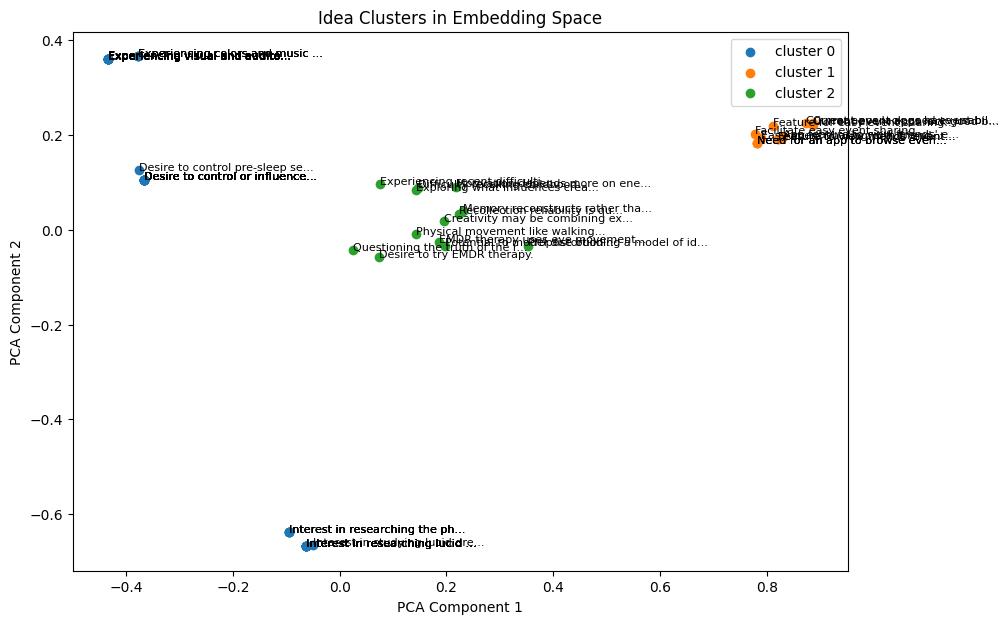

In [61]:
pca = PCA(n_components=2)
points_2d = pca.fit_transform(vectors)

cluster_vis_df = cluster_df.copy()
cluster_vis_df["x"] = points_2d[:, 0]
cluster_vis_df["y"] = points_2d[:, 1]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(cluster_vis_df["cluster"].unique()):
    subset = cluster_vis_df[cluster_vis_df["cluster"] == cluster_id]
    plt.scatter(subset["x"], subset["y"], label=f"cluster {cluster_id}")

for _, row in cluster_vis_df.iterrows():
    short_label = (
        row["summary"][:30] + "..." if len(row["summary"]) > 30 else row["summary"]
    )
    plt.text(row["x"], row["y"], short_label, fontsize=8)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Idea Clusters in Embedding Space")
plt.legend()
plt.show()
# later we can use llm to see what each cluster has in common!!!!!

#### Graph-Based Structural Exploration

Clustering provides a global grouping of ideas, while the graph view highlights local semantic connectivity.

The interactive graph is constructed from the semantic links stored in `idea_links`. Nodes represent ideas, and edges represent semantic similarity above a chosen threshold. To make the structure easier to interpret, node colors are assigned according to the clusters computed above.

This view complements clustering by showing how local neighborhoods, cross-cluster connections, and structural bridges appear within the broader idea space.

Clustering and graph rendering are not part of the core storage pipeline. They are analytical tools built on top of the structured knowledge representation.

Clustering and visualization are not part of the core storage pipeline. They are analytical layers built on top of the structured knowledge representation.

In [62]:
# map idea_id to cluster
cluster_map = dict(zip(embeddings_df["idea_id"], labels))

colors = [
    "#ff6b6b",
    "#4ecdc4",
    "#ffe66d",
    "#5f27cd",
    "#1dd1a1",
]

graph = nx.Graph()

# add nodes with cluster colors
for _, row in ideas_df.iterrows():
    idea_id = row["idea_id"]
    label = row["main_domain"].capitalize() + ": \n" + row["summary"]
    short_label = label[:35] + "..." if len(label) > 35 else label

    cluster = cluster_map.get(idea_id, 0)
    color = colors[cluster % len(colors)]

    graph.add_node(
        idea_id,
        label=short_label,
        title=f"{label} | Cluster: #{cluster}",
        color=color,
    )

# add edges above threshold
threshold = 0.35

for _, row in semantic_df.iterrows():
    if row["score"] >= threshold:
        graph.add_edge(
            row["source_idea_id"],
            row["target_idea_id"],
            value=row["score"],
            title=f"similarity: {row['score']:.3f}",
        )

net = Network(
    height="700px",
    width="100%",
    notebook=False,
    cdn_resources="in_line",
)

net.from_nx(graph)

net.set_options(
    """
var options = {
  "physics": {
    "enabled": true,
    "barnesHut": {
      "gravitationalConstant": -2000,
      "springLength": 180,
      "springConstant": 0.04
    },
    "minVelocity": 0.75
  },
  "nodes": {
    "shape": "dot",
    "size": 18,
    "font": {
      "size": 10
    }
  },
  "edges": {
    "smooth": false
  },
  "interaction": {
    "hover": true,
    "navigationButtons": true,
    "keyboard": true
  }
}
"""
)


output_path = "../data/idea_network_clustered.html"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

full_path = os.path.abspath(output_path)

html = net.generate_html()

with open(full_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"graph saved to: {full_path}")
webbrowser.open(f"file://{full_path}")

graph saved to: c:\Users\oyoli\projects\personal-knowledge-system\data\idea_network_clustered.html


True

<img src="../images/final_graph.png" width="50%">
